Apply Principal Component Analysis (PCA) and Linear Discriminant Analysis (LDA) on MNIST dataset. Compare the performance of PCA vs. LDA for classifying handwritten digits (MNIST dataset).

In [2]:
import pandas as pd
from sklearn.decomposition import PCA
# import cupy as cp
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from cuml.neighbors import KNeighborsClassifier
import pandas as pd
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier
from cuml.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Loading the MNIST train and test csv

In [3]:
train_set = pd.read_csv("../datasets/mnist_train.csv")
test_set = pd.read_csv("../datasets/mnist_test.csv")

In [4]:
train_set["label"].unique()

array([5, 0, 4, 1, 9, 2, 3, 6, 7, 8])

In [5]:
train_set

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
test_set

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
train_set.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,4.453933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,2.889270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


In [8]:
test_set.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,10000.000000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,...,10000.000000,10000.000000,10000.000000,10000.0000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,4.443400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.179300,0.163600,0.052600,0.0006,0.0,0.0,0.0,0.0,0.0,0.0
std,2.895865,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.674149,5.736072,2.420004,0.0600,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,253.000000,156.000000,6.0000,0.0,0.0,0.0,0.0,0.0,0.0


The MNIST dataset contains 10 classes(0 to 9) of handwritten digits each of size 28x28

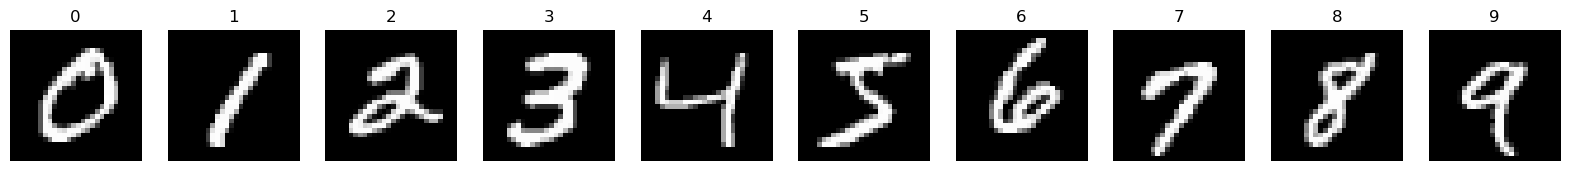

In [9]:
plt.subplots(1, 10, figsize=(20, 17))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    # plt.imshow(train_set[train_set["label"] == i].values[0][1:].reshape(28, 28), cmap="gray")
    image = train_set[train_set["label"] == i].to_numpy()[0][1:].reshape(28, 28)
    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.title(i)
plt.show()


In [10]:
train_set_copy = train_set.copy()
train_set_copy = train_set_copy.drop(columns=["label"])

In [11]:
test_set_copy = test_set.copy()
test_set_copy = test_set_copy.drop(columns=["label"])


Scaling the values of both the sets


In [12]:
std_scaler = StandardScaler()
train_set_scaled = std_scaler.fit_transform(train_set_copy)
test_set_scaled = std_scaler.transform(test_set_copy)

Applying PCA on the dataset

In [13]:
pca = PCA(n_components=9)
train_set_pca = pca.fit_transform(train_set_copy.to_numpy())
pca.explained_variance_ratio_


array([0.09704664, 0.07095924, 0.06169089, 0.05389419, 0.04868797,
       0.04312231, 0.0327193 , 0.02883895, 0.02762029])

In [14]:
test_set_pca = pca.fit_transform(test_set_copy.to_numpy())

Applying LDA on the dataset

In [15]:
lda = LinearDiscriminantAnalysis(n_components=9)
train_set_lda = lda.fit_transform(train_set_copy.to_numpy(), train_set["label"].to_numpy())
lda.explained_variance_ratio_

array([0.2392286 , 0.20180995, 0.17849695, 0.10652571, 0.09406712,
       0.06906025, 0.04973746, 0.03429077, 0.0267832 ])

In [16]:
test_set_lda = lda.fit_transform(test_set_copy.to_numpy(), test_set["label"].to_numpy())


Training two SVMs on the two train sets

In [17]:
# knn_01 = SVC(kernel="linear")
knn_01 = KNeighborsClassifier(n_neighbors=3)

# knn_02 = SVC(kernel="linear")
knn_02 = KNeighborsClassifier(n_neighbors=3)


In [18]:
# svc_01.fit(train_set_pca, train_set["label"])
knn_01.fit(train_set_pca, train_set["label"])

KNeighborsClassifier()

In [19]:

# svc_02.fit(train_set_lda, train_set["label"])
knn_02.fit(train_set_lda, train_set["label"])

KNeighborsClassifier()

Evaluating the performance of the two SVMs

In [20]:
# pred_01 = svc_01.predict(test_set_pca)
pred_01 = knn_01.predict(test_set_pca)
# pred_01 = cp.asnumpy(pred_01)

In [ ]:
# pred_02 = svc_02.predict(test_set_lda)
pred_02 = knn_02.predict(test_set_lda)
# pred_02 = cp.asnumpy(pred_02)

In [23]:
print("PCA Classification Report")
print(classification_report(test_set["label"], pred_01))

PCA Classification Report
              precision    recall  f1-score   support

           0       0.77      0.82      0.79       980
           1       0.90      0.57      0.69      1135
           2       0.48      0.59      0.53      1032
           3       0.63      0.75      0.68      1010
           4       0.66      0.72      0.69       982
           5       0.63      0.63      0.63       892
           6       0.30      0.24      0.27       958
           7       0.62      0.69      0.65      1028
           8       0.68      0.68      0.68       974
           9       0.66      0.61      0.63      1009

    accuracy                           0.63     10000
   macro avg       0.63      0.63      0.63     10000
weighted avg       0.64      0.63      0.63     10000



<Axes: >

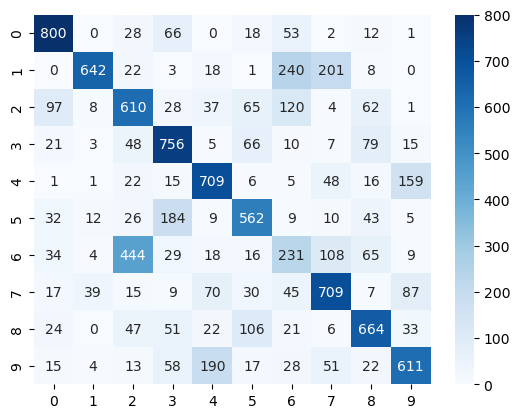

In [24]:
confusion_matrix_01 = confusion_matrix(test_set["label"], pred_01)
sns.heatmap(confusion_matrix_01, annot=True, fmt="d", cmap="Blues")

In [25]:
print("LDA Classification Report")
print(classification_report(test_set["label"], pred_02))

LDA Classification Report
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       980
           1       0.90      0.81      0.85      1135
           2       0.91      0.92      0.91      1032
           3       0.88      0.90      0.89      1010
           4       0.88      0.93      0.91       982
           5       0.88      0.86      0.87       892
           6       0.95      0.95      0.95       958
           7       0.68      0.94      0.79      1028
           8       0.87      0.83      0.85       974
           9       0.91      0.66      0.76      1009

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



<Axes: >

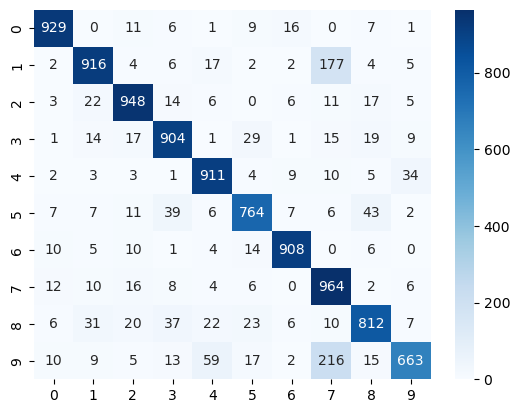

In [26]:
confusion_matrix_02 = confusion_matrix(test_set["label"], pred_02)
sns.heatmap(confusion_matrix_02, annot=True, fmt="d", cmap="Blues")